## Simulation-based sensitivity analysis

## Setup

In [1]:
# Import libraries
library(simr)
library(lme4)
library(ggplot2)

Loading required package: lme4

Loading required package: Matrix


Attaching package: 'simr'


The following object is masked from 'package:lme4':

    getData




In [2]:
# Load models
model_hr <- readRDS("models/model_hr.rds")
model_rr <- readRDS("models/model_rr.rds")

# Check model classes
class(model_hr)
class(model_rr)

[1] "lmerModLmerTest"
attr(,"package")
[1] "lmerTest"

[1] "lmerModLmerTest"
attr(,"package")
[1] "lmerTest"

## Custom function definitions

In [3]:
# Create function to recreate an artificial model with the same fixed effects structure plus new random effects and additional samples
make_model <- function(formula, n_ids, effect_size, fe,
                        var_id, sigma, grid) {
                            participants <- factor(sprintf("vrt_simulated%2d", 1:n_ids))
                            covars <- expand.grid(
                                ID = participants,
                                session = factor(session_levels, levels = session_levels),
                                group = factor(group_levels, levels = group_levels),
                                instrument_type = factor(instr_levels, levels = instr_levels)
                            )
                            # Set the fixed effect values
                            b <- fe
                            b["groupexp:sessionExam"] <- effect_size

                            # Build the artificial model with new random effects draws
                            makeLmer(formula = formula,
                                     fixef = b,
                                     VarCorr = list(ID = var_id),
                                     sigma = sigma,
                                     data = covars)
                        }

In [18]:
# Create function for visualizing power and effect size combinations
visualize_power_estimates <- function(grid) {
        p_power <- ggplot(grid,
                  aes(x = sample_sizes, y = power, color = factor(effect_sizes), group = factor(effect_sizes))) +
  geom_hline(yintercept = 0.80, linetype = "dashed", color = "grey40") +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
  scale_x_continuous(breaks = sort(unique(grid$sample_sizes))) +
  labs(
    x = "Number of participants",
    y = "Power",
    color = "Effect size"
  ) +
  theme_minimal(base_size = 13)

p_power
}

# ggsave("power_curve_positive_effects.png", p_power, width = 8, height = 5, dpi = 300)

## Heart rate

### Refit model in lme4 so that powerSim and simr can handle it properly
--> to avoid this: "long vectors not supported yet: subassign.c:1841" 

In [27]:
# Extract formula and data from the original model
formula_hr <- formula(model_hr)
# Retrieve the original data used to fit the model
dat_hr  <- simr::getData(model_hr)

# Refit using lme4 (no lmerTest)
model_hr_lme4 <- lmer(formula_hr, data = dat_hr, REML = TRUE)

# Check model summary
summary(model_hr_lme4)

Linear mixed model fit by REML ['lmerMod']
Formula: HR ~ group * session + instrument_type + (1 | ID)
   Data: dat_hr

REML criterion at convergence: 353.6

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.08158 -0.38604 -0.08492  0.64710  1.85533 

Random effects:
 Groups   Name        Variance Std.Dev.
 ID       (Intercept)  93.84    9.687  
 Residual             369.55   19.224  
Number of obs: 45, groups:  ID, 15

Fixed effects:
                              Estimate Std. Error t value
(Intercept)                     95.521      9.166  10.421
groupexp                        -4.493     11.379  -0.395
sessionResting state           -11.667     11.099  -1.051
sessionExam                     25.833     11.099   2.328
instrument_type1                14.438      7.813   1.848
groupexp:sessionResting state   -1.889     14.329  -0.132
groupexp:sessionExam             6.056     14.329   0.423

Correlation of Fixed Effects:
            (Intr) gropxp sssnRs sssnEx inst_1 gr

In [7]:
# Create effect sizes and sample sizes to loop through
# Use CI to define a realistic range of effect sizes
effect_sizes_hr = c(1, 5, 10, 15, 20)
sample_sizes_hr = c(30, 40, 50, 60, 70, 80, 90)

# Create grid for each combination of effect size and sample size
grid_hr = expand.grid(effect_sizes = effect_sizes_hr, 
                    sample_sizes = sample_sizes_hr)
# Add a column to store power results
grid_hr$power <- NA


In [8]:
# Get fixed effect structure from the model
fixef_hr <- fixef(model_hr_lme4)

# Extract variance components
vc_hr <- as.data.frame(VarCorr(model_hr_lme4))
var_ID_intercept_hr <- vc_hr$vcov[vc_hr$grp == "ID" & vc_hr$var1 == "(Intercept)"]
sigma_res_hr <- sigma(model_hr_lme4)

# Define the formula of the model
formula_hr <- HR ~ group * session + instrument_type + (1 | ID)

# Define factor levels
session_levels <- c("Baseline","Resting state","Exam")
group_levels   <- c("ctr","exp")
instr_levels   <- c("2","1") 


In [23]:
# Loop thorugh the grid and calculate power for each combination
for (i in 1:nrow(grid_hr)) {
  # Extract effect size and sample size
  effect_size <- grid_hr$effect_sizes[i]
  sample_size <- grid_hr$sample_sizes[i]

  # Copy the original model
  m <- make_model(formula = formula_hr, n_ids = sample_size, effect_size = effect_size,
                  fe = fixef_hr,
                  var_id = var_ID_intercept_hr,
                  sigma = sigma_res_hr,
                  grid = grid_hr)

  # Check whether the artificial model is singular
  if (isSingular(m)) message("Model is singular with effect size ", effect_size, 
                            " and sample size ", sample_size)


  # Set effect size
  fixef(m)["groupexp:sessionExam"] <- effect_size
  
  # Calculate power using simr
  power_result <- powerSim(m, 
                           fixed("groupexp:sessionExam", "z"), 
                           nsim = 100,
                           progress = FALSE
                           )
  
  # Store the power result in the grid
  grid_hr$power[i] <- if (!is.null(summary(power_result)$mean)) summary(power_result)$mean else NA
}

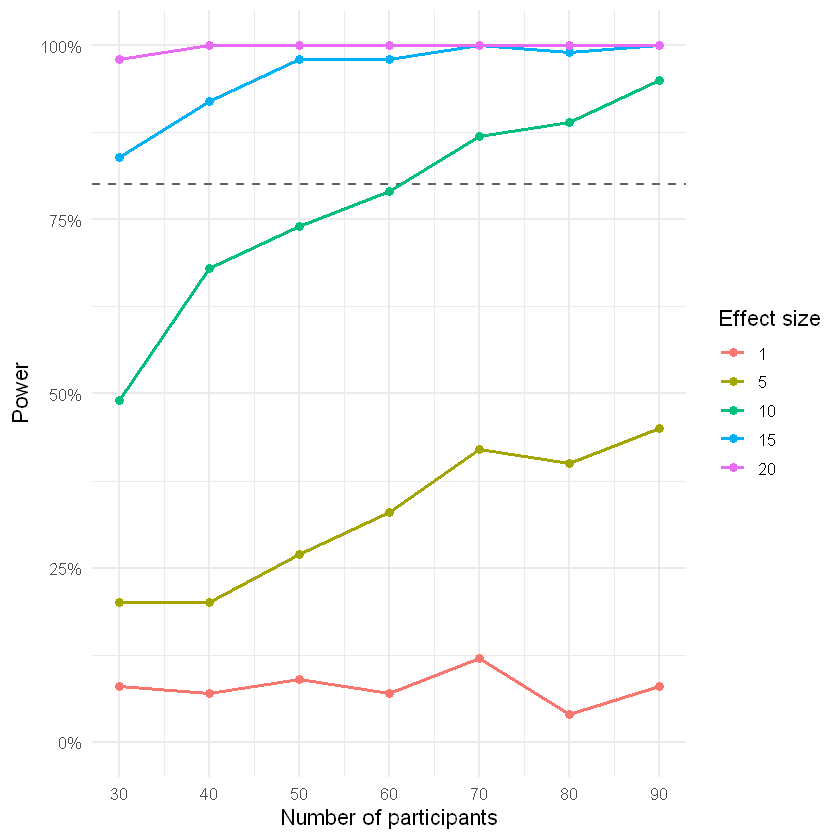

In [24]:
# Visual power sample size for 
fog_pa_hr <- visualize_power_estimates(grid_hr)
fog_pa_hr

In [34]:
# Save as figure
ggsave("sensitivity_curve_hr.png", fog_pa_hr, width = 8, height = 5, dpi = 300)

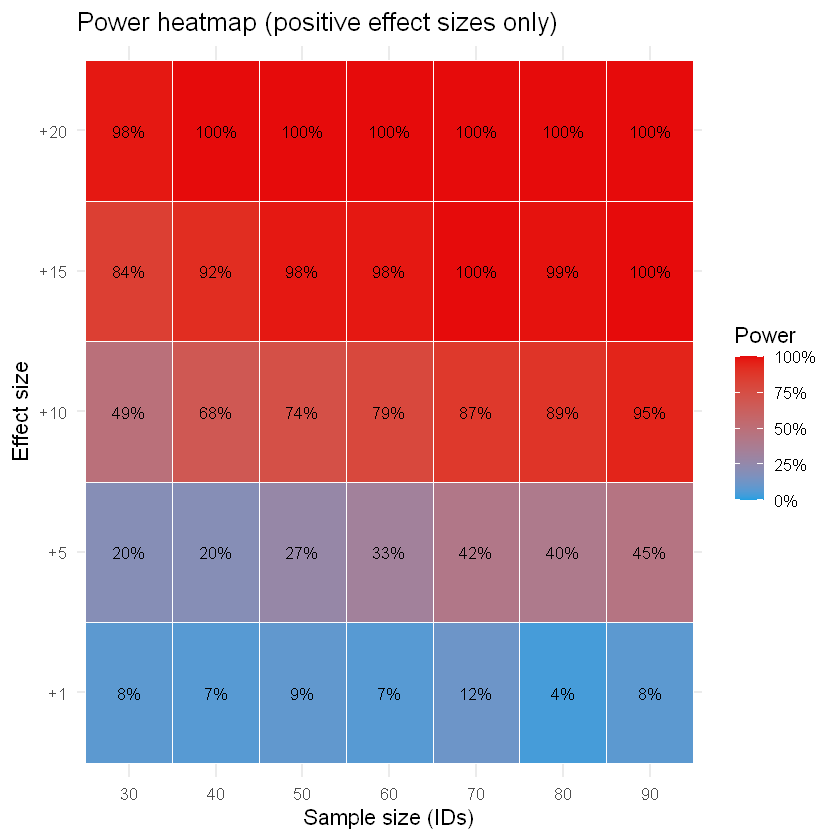

In [25]:
# Create a heatmap for
library(ggplot2)

grid_pos <- subset(grid_hr, effect_sizes > 0 & !is.na(power))
grid_pos$effect_label <- factor(paste0("+", grid_pos$effect_sizes),
                                levels = paste0("+", sort(unique(grid_pos$effect_sizes))))

p_heat <- ggplot(grid_pos, aes(x = factor(sample_sizes), y = effect_label, fill = power)) +
  geom_tile(color = "white") +
  geom_text(aes(label = scales::percent(power, accuracy = 1)), color = "black", size = 3.5) +
  scale_fill_gradient(low = "#1ca0e2", high = "#e60b0b",
                      labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
  labs(
    title = "Power heatmap (positive effect sizes only)",
    x = "Sample size (IDs)",
    y = "Effect size",
    fill = "Power"
  ) +
  theme_minimal(base_size = 13)

p_heat
# ggsave("power_heatmap_positive_effects.png", p_heat, width = 7, height = 5, dpi = 300)



## Respiratory rate

In [28]:
# Extract formula and data from the original model
formula_rr <- formula(model_rr)
# Retrieve the original data used to fit the model
dat_rr  <- simr::getData(model_rr)

# Refit using lme4 (no lmerTest)
model_rr_lme4 <- lmer(formula_rr, data = dat_rr, REML = TRUE)

# Check model summary
summary(model_rr_lme4)

Linear mixed model fit by REML ['lmerMod']
Formula: RSP_Rate_Mean ~ group * session + instrument_type + (1 | ID)
   Data: dat_rr

REML criterion at convergence: 211.9

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.88378 -0.62709 -0.03704  0.59435  1.70955 

Random effects:
 Groups   Name        Variance Std.Dev.
 ID       (Intercept)  0.7317  0.8554  
 Residual             16.1278  4.0159  
Number of obs: 42, groups:  ID, 14

Fixed effects:
                              Estimate Std. Error t value
(Intercept)                   19.22999    1.73823  11.063
groupexp                       2.90116    2.21826   1.308
sessionResting state          -0.09749    2.31861  -0.042
sessionExam                   -1.76052    2.31861  -0.759
instrument_type1              -6.57464    1.37974  -4.765
groupexp:sessionResting state -3.70141    3.06723  -1.207
groupexp:sessionExam           2.42955    3.06723   0.792

Correlation of Fixed Effects:
            (Intr) gropxp sssnRs sssnE

In [68]:
# Create effect sizes and sample sizes to loop through
# Use CI to define a realistic range of effect sizes
effect_sizes_rr = c(1, 2.5, 4, 5.5, 7)
sample_sizes_rr = c(30, 40, 50, 60, 70, 80, 90)

# Create grid for each combination of effect size and sample size
grid_rr = expand.grid(effect_sizes = effect_sizes_rr, 
                    sample_sizes = sample_sizes_rr)
# Add a column to store power results
grid_rr$power <- NA

In [50]:
# Get fixed effect structure from the model
fixef_rr <- fixef(model_rr_lme4)

# Extract variance components
vc_rr <- as.data.frame(VarCorr(model_rr_lme4))
var_ID_intercept_rr <- vc_rr$vcov[vc_rr$grp == "ID" & vc_rr$var1 == "(Intercept)"]
sigma_res_rr <- sigma(model_rr_lme4)

# Define the formula of the model
formula_rr <- RSP_Rate_mean ~ group * session + instrument_type + (1 | ID)

# Define factor levels
session_levels <- c("Baseline","Resting state","Exam")
group_levels   <- c("ctr","exp")
instr_levels   <- c("2","1") 


In [ ]:
# The ICC of model_rr is only 0.043 (see Vrtraining_with_pymer4.ipynb), 
# thus in many simulation rounds the random intercept estimate is often close to zero. 
# Which leads to a singularity issue warning. However, the the simulation still provides valid power estimates,
# suppress warnings didn't work so I deletet the cell output for an better readibility.

# Loop thorugh the grid and calculate power for each combination
for (i in 1:nrow(grid_rr)) {
  # Extract effect size and sample size
  effect_size <- grid_rr$effect_sizes[i]
  sample_size <- grid_rr$sample_sizes[i]

  # Copy the original model
  m <- make_model(formula = formula_rr, n_ids = sample_size, effect_size = effect_size,
                  fe = fixef_rr,
                  var_id = var_ID_intercept_rr,
                  sigma = sigma_res_rr,
                  grid = grid_rr)

  # Check whether the artificial model is singular
  if (isSingular(m)) message("Model is singular with effect size ", effect_size, 
                            " and sample size ", sample_size)


  # Set effect size
  fixef(m)["groupexp:sessionExam"] <- effect_size
  
  # Calculate power using simr
  power_result <- suppressWarnings(powerSim(m, 
                           fixed("groupexp:sessionExam", "z"), 
                           nsim = 100,
                           progress = FALSE
                           ))
  
  # Store the power result in the grid
  grid_rr$power[i] <- if (!is.null(summary(power_result)$mean)) summary(power_result)$mean else NA


}

In [70]:
# Check the resulting grid object
grid_rr

effect_sizes,sample_sizes,power
<dbl>,<dbl>,<dbl>
1.0,30,0.12
2.5,30,0.64
4.0,30,0.99
5.5,30,1.00
7.0,30,1.00
1.0,40,0.18
2.5,40,0.78
4.0,40,0.99
5.5,40,1.00


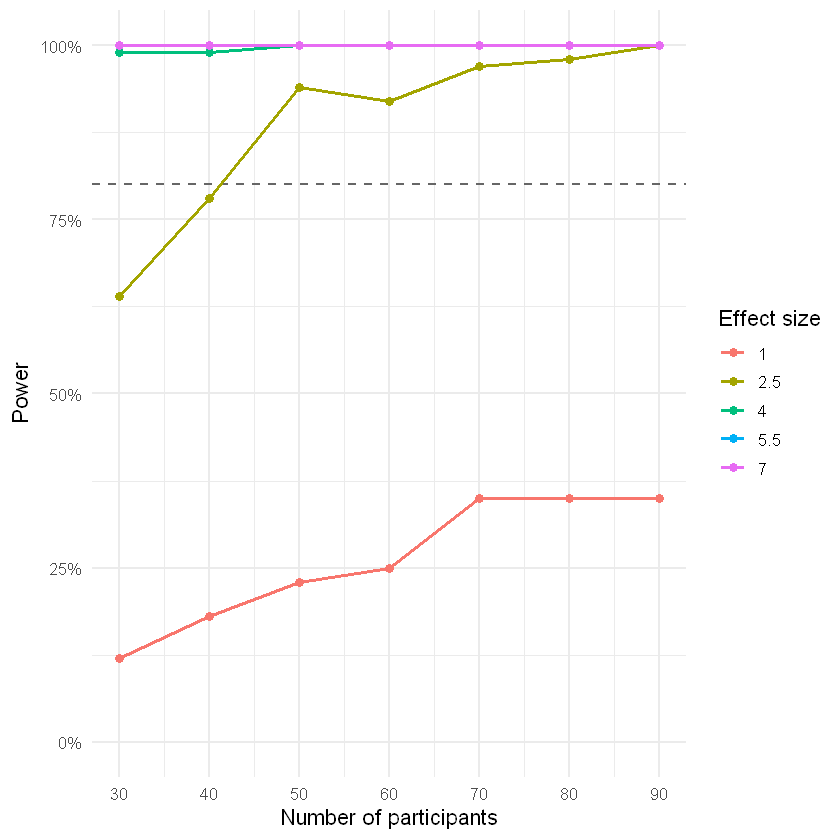

In [71]:
# Visual power sample size for 
fog_pa_rr <- visualize_power_estimates(grid_rr)
fog_pa_rr

In [72]:
# Save as figure
ggsave("sensitivity_curve_rr.png", fog_pa_rr, width = 8, height = 5, dpi = 300)